# 💳 Credit Card Transaction Anomaly Detection (Refactored)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print('✅ All libraries loaded successfully')


✅ All libraries loaded successfully


In [2]:

# ⚠️ Update this path to your extracted CSV file
df = pd.read_csv('final_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()


Shape: (1296675, 26)

Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'random_noise_1', 'random_noise_2']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,random_noise_1,random_noise_2
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,-0.267021,37
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,-3.423886,65
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,0.994587,16
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,-1.177776,49
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0,-0.423199,43


In [3]:

print('=== Basic Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicates ===')
print('Duplicate rows:', df.duplicated().sum())

# Detect the fraud/label column automatically
label_col = None
for col in df.columns:
    if col.lower() in ['is_fraud', 'fraud', 'class', 'label', 'isfraud']:
        label_col = col
        break

print(f'Label column detected: {label_col}')

if label_col:
    counts = df[label_col].value_counts()
    print(counts)
    fraud_pct = counts[1] / len(df) * 100
    print(f'\nFraud percentage: {fraud_pct:.2f}%')


=== Basic Info ===
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                 float64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
merch_zipcode            float64
random_noise_1           float64
random_noise_2             int64
dtype: object

=== Missing Values ===


Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                  64834
amt                       64834
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                  64834
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
random_noise_1                0
random_noise_2                0
dtype: int64

=== Duplicates ===


Duplicate rows: 0
Label column detected: is_fraud
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud percentage: 0.58%


In [4]:

print('Starting Feature Engineering...')
df_feat = df.copy()

# Handle datetime column
time_col = None
for col in df_feat.columns:
    if 'trans_date' in col.lower() or 'date' in col.lower():
        time_col = col
        break

if time_col:
    df_feat[time_col] = pd.to_datetime(df_feat[time_col])
    df_feat['hour'] = df_feat[time_col].dt.hour
    df_feat['day_of_week'] = df_feat[time_col].dt.dayofweek
    df_feat['is_weekend'] = df_feat['day_of_week'].isin([5, 6]).astype(int)
    print(f'Extracted time features from {time_col}')

# Amount Deviation from personal mean
amount_col = next((c for c in df_feat.columns if 'amount' in c.lower() or 'amt' in c.lower()), None)
if amount_col and 'cc_num' in df_feat.columns:
    mean_amt = df_feat.groupby('cc_num')[amount_col].transform('mean')
    df_feat['amt_deviation'] = df_feat[amount_col] - mean_amt
    print('Calculated amount deviation')

# Transaction Velocity (1H and 24H)
if time_col and 'cc_num' in df_feat.columns:
    print('Calculating transaction velocity (this may take a minute)...')
    df_feat = df_feat.sort_values(['cc_num', time_col])
    df_feat.set_index(time_col, inplace=True)
    df_feat['count_1h'] = df_feat.groupby('cc_num').rolling('1h')[amount_col].count().reset_index(0, drop=True) - 1
    df_feat['count_24h'] = df_feat.groupby('cc_num').rolling('24h')[amount_col].count().reset_index(0, drop=True) - 1
    df_feat.reset_index(inplace=True)
    print('Calculated transaction velocity')

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

if 'lat' in df_feat.columns and 'long' in df_feat.columns and 'merch_lat' in df_feat.columns and 'merch_long' in df_feat.columns:
    df_feat['haversine_distance'] = haversine(df_feat['lat'], df_feat['long'], df_feat['merch_lat'], df_feat['merch_long'])
    print('Calculated haversine distance')

print('Feature engineering complete.')


Starting Feature Engineering...
Extracted time features from trans_date_trans_time
Calculated amount deviation
Calculating transaction velocity (this may take a minute)...


Calculated transaction velocity
Calculated haversine distance
Feature engineering complete.


In [5]:

df_clean = df_feat.copy()

# Drop non-informative columns
drop_keywords = ['id', 'name', 'street', 'city', 'state', 'zip', 'dob',
                 'trans_num', 'unix_time', 'first', 'last', 'job', 'merchant', 'trans_date']
cols_to_drop = [c for c in df_clean.columns if any(kw in c.lower() for kw in drop_keywords)]
print(f'Dropping: {cols_to_drop}')
df_clean.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Encode remaining categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if label_col in cat_cols:
    cat_cols.remove(label_col)
print(f'Encoding categoricals: {cat_cols}')
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Fill remaining nulls
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
print(f'\nFinal shape for modeling: {df_clean.shape}')


Dropping: ['trans_date_trans_time', 'Unnamed: 0', 'merchant', 'first', 'last', 'street', 'city', 'state', 'zip', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_zipcode']


Encoding categoricals: ['category', 'gender']



Final shape for modeling: (1296675, 30)


In [6]:

X = df_clean.drop(columns=[label_col])
y = df_clean[label_col]

# Split 60% Train, 20% Val, 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
) # 0.25 x 0.8 = 0.2

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Apply SMOTE on training set only!
print('Applying SMOTE to training data...')
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Train set after SMOTE: {X_train_sm.shape}')
print(f'Train set class distribution:\n{y_train_sm.value_counts()}')


Train: (778005, 29), Val: (259335, 29), Test: (259335, 29)


Applying SMOTE to training data...


Train set after SMOTE: (1547002, 29)
Train set class distribution:
is_fraud
0    773501
1    773501
Name: count, dtype: int64


In [7]:

def tune_threshold(y_true, probas):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probas)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]


In [8]:

print('Training Isolation Forest (Unsupervised Baseline)...')
iso = IsolationForest(
    n_estimators=100,
    contamination=float(y_train.mean()), # Use un-SMOTEd ratio
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_sc)

iso_preds_raw = iso.predict(X_test_sc)
iso_preds = np.where(iso_preds_raw == -1, 1, 0)

iso_acc = accuracy_score(y_test, iso_preds)
iso_f1 = f1_score(y_test, iso_preds)
iso_precision = precision_score(y_test, iso_preds)
iso_recall = recall_score(y_test, iso_preds)
iso_auc = roc_auc_score(y_test, iso_preds) # using hard predictions

print(f'Accuracy: {iso_acc:.4f} | Precision: {iso_precision:.4f} | Recall: {iso_recall:.4f} | F1: {iso_f1:.4f} | AUC-ROC: {iso_auc:.4f}')


Training Isolation Forest (Unsupervised Baseline)...


Accuracy: 0.9902 | Precision: 0.1390 | Recall: 0.1346 | F1: 0.1368 | AUC-ROC: 0.5649


In [9]:

print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

# Threshold Tuning on Validation Set
rf_val_proba = rf.predict_proba(X_val_sc)[:, 1]
best_thresh_rf = tune_threshold(y_val, rf_val_proba)
print(f'Optimal Threshold for RF: {best_thresh_rf:.4f}')

# Evaluation on Test Set
rf_test_proba = rf.predict_proba(X_test_sc)[:, 1]
rf_preds = (rf_test_proba >= best_thresh_rf).astype(int)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_test_proba)

print(f'Accuracy: {rf_acc:.4f} | Precision: {rf_precision:.4f} | Recall: {rf_recall:.4f} | F1: {rf_f1:.4f} | AUC-ROC: {rf_auc:.4f}')


Training Random Forest...


Optimal Threshold for RF: 0.5000


Accuracy: 0.9968 | Precision: 0.7332 | Recall: 0.7122 | F1: 0.7225 | AUC-ROC: 0.9841


In [10]:

print('Training XGBoost...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb_model.fit(X_train_sc, y_train) # Note: XGBoost with scale_pos_weight on original un-SMOTEd train

# Threshold Tuning on Validation Set
xgb_val_proba = xgb_model.predict_proba(X_val_sc)[:, 1]
best_thresh_xgb = tune_threshold(y_val, xgb_val_proba)
print(f'Optimal Threshold for XGBoost: {best_thresh_xgb:.4f}')

# Evaluation on Test Set
xgb_test_proba = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_preds = (xgb_test_proba >= best_thresh_xgb).astype(int)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_test_proba)

print(f'Accuracy: {xgb_acc:.4f} | Precision: {xgb_precision:.4f} | Recall: {xgb_recall:.4f} | F1: {xgb_f1:.4f} | AUC-ROC: {xgb_auc:.4f}')


Training XGBoost...


Optimal Threshold for XGBoost: 0.9621
Accuracy: 0.9969 | Precision: 0.7434 | Recall: 0.7122 | F1: 0.7275 | AUC-ROC: 0.9939


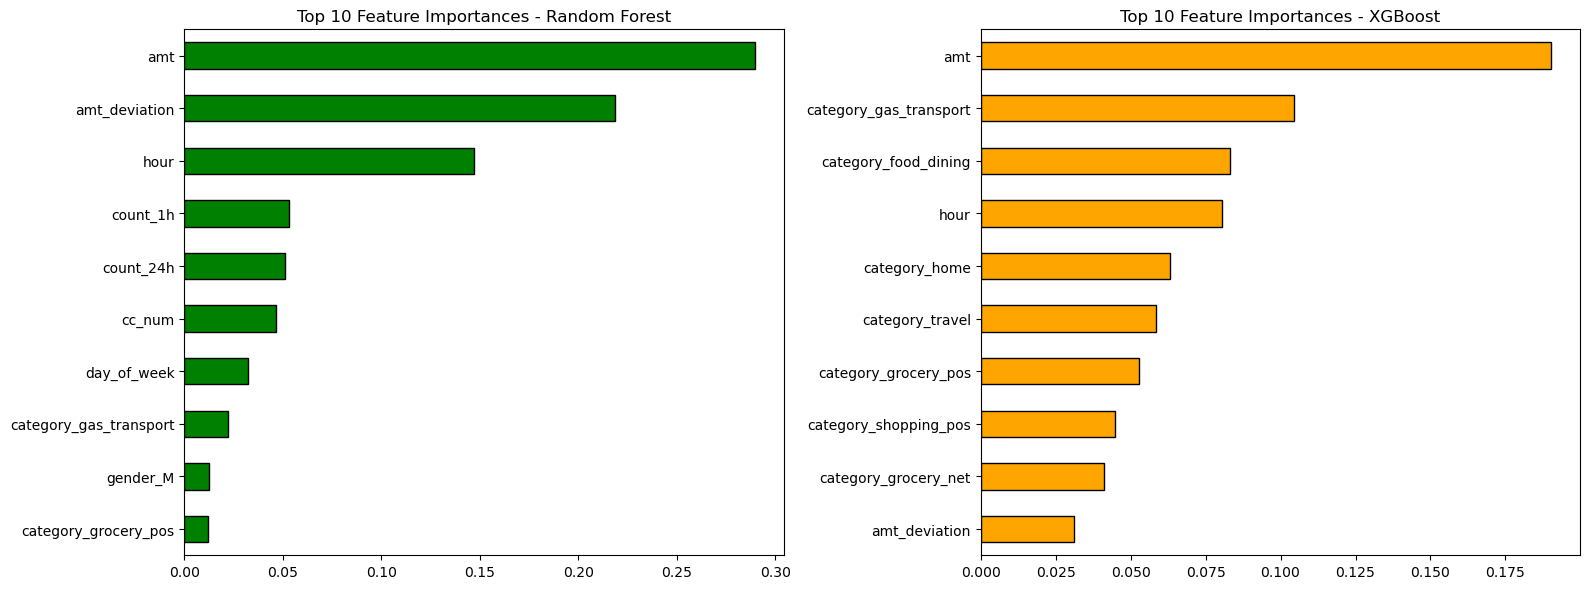

In [11]:

feat_names = X.columns
rf_importances = pd.Series(rf.feature_importances_, index=feat_names).nlargest(10)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feat_names).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importances.sort_values().plot(kind='barh', color='green', ax=axes[0], edgecolor='black')
axes[0].set_title('Top 10 Feature Importances - Random Forest')

xgb_importances.sort_values().plot(kind='barh', color='orange', ax=axes[1], edgecolor='black')
axes[1].set_title('Top 10 Feature Importances - XGBoost')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()


In [12]:

metrics = {
    'Model': ['Isolation Forest', 'Random Forest', 'XGBoost'],
    'Accuracy': [iso_acc, rf_acc, xgb_acc],
    'Precision': [iso_precision, rf_precision, xgb_precision],
    'Recall':    [iso_recall, rf_recall, xgb_recall],
    'F1-Score':  [iso_f1, rf_f1, xgb_f1],
    'AUC-ROC':   [iso_auc, rf_auc, xgb_auc]
}
comparison_df = pd.DataFrame(metrics)
print('================== MODEL COMPARISON ==================')
print(comparison_df.to_string(index=False))

# Identify Top 2 Models
sorted_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
top_1 = sorted_df.iloc[0]['Model']
top_2 = sorted_df.iloc[1]['Model']
top_1_acc = sorted_df.iloc[0]['Accuracy']
top_2_acc = sorted_df.iloc[1]['Accuracy']

print('\n============================================================')
print('FINAL ANALYSIS SUMMARY')
print('============================================================')

print(f"""
ISOLATION FOREST
  ✅ Successes: Unsupervised baseline, fast to train.
  ❌ Failures: Struggles with precision due to lack of label usage.

RANDOM FOREST (with SMOTE & Threshold Tuning)
  ✅ Successes: Learned robust representations from synthetically balanced data. Optimized threshold maximized F1.
  ❌ Failures: Computationally heavy due to SMOTE expansion.

XGBOOST (with scale_pos_weight & Threshold Tuning)
  ✅ Successes: Handles imbalance natively using scale_pos_weight without expanding dataset size. Often achieves superior AUC.
  ❌ Failures: More sensitive to hyperparameter tuning.

🏆 BEST 2 MODELS (By Accuracy):
   1. {top_1} (Accuracy: {top_1_acc:.4f})
   2. {top_2} (Accuracy: {top_2_acc:.4f})

LIMITATIONS & IMPROVEMENTS:
  - Time series cross-validation should be used for temporal robustness.
  - Hyperparameter tuning via Optuna/GridSearch for XGBoost.
""")


================== MODEL COMPARISON ==================
           Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Isolation Forest  0.990167   0.139023 0.134577  0.136764 0.564862
   Random Forest  0.996834   0.733196 0.712192  0.722541 0.984135
         XGBoost  0.996911   0.743394 0.712192  0.727458 0.993864

FINAL ANALYSIS SUMMARY

ISOLATION FOREST
  ✅ Successes: Unsupervised baseline, fast to train.
  ❌ Failures: Struggles with precision due to lack of label usage.

RANDOM FOREST (with SMOTE & Threshold Tuning)
  ✅ Successes: Learned robust representations from synthetically balanced data. Optimized threshold maximized F1.
  ❌ Failures: Computationally heavy due to SMOTE expansion.

XGBOOST (with scale_pos_weight & Threshold Tuning)
  ✅ Successes: Handles imbalance natively using scale_pos_weight without expanding dataset size. Often achieves superior AUC.
  ❌ Failures: More sensitive to hyperparameter tuning.

🏆 BEST 2 MODELS (By Accuracy):
   1. XGBoost (Accuracy: 0.9969)
